In [2]:
#Importacion de librerias

# Pandas: lectura y preprocesamiento del dataset
import pandas as pd

# NumPy: cómputo vectorial y matricial (operaciones del modelo)
import numpy as np

# Matplotlib: graficación de resultados
from matplotlib import pyplot

# Embeber gráficas dentro del cuadernillo
%matplotlib inline

In [3]:
#Carga del data set
df = pd.read_csv('/content/dataset.csv')

# Listar todas las columnas
print("LISTA DE TODAS LAS COLUMNAS")
for i, col in enumerate(df.columns):
    print(f"  [{i+1:02d}] {col}")
print()

# Primeras 5 filas para visualizar estructura
print("PRIMERAS 5 FILAS")
df.head()

LISTA DE TODAS LAS COLUMNAS
  [01] number_of_elements
  [02] mean_atomic_mass
  [03] wtd_mean_atomic_mass
  [04] gmean_atomic_mass
  [05] wtd_gmean_atomic_mass
  [06] entropy_atomic_mass
  [07] wtd_entropy_atomic_mass
  [08] range_atomic_mass
  [09] wtd_range_atomic_mass
  [10] std_atomic_mass
  [11] wtd_std_atomic_mass
  [12] mean_fie
  [13] wtd_mean_fie
  [14] gmean_fie
  [15] wtd_gmean_fie
  [16] entropy_fie
  [17] wtd_entropy_fie
  [18] range_fie
  [19] wtd_range_fie
  [20] std_fie
  [21] wtd_std_fie
  [22] mean_atomic_radius
  [23] wtd_mean_atomic_radius
  [24] gmean_atomic_radius
  [25] wtd_gmean_atomic_radius
  [26] entropy_atomic_radius
  [27] wtd_entropy_atomic_radius
  [28] range_atomic_radius
  [29] wtd_range_atomic_radius
  [30] std_atomic_radius
  [31] wtd_std_atomic_radius
  [32] mean_Density
  [33] wtd_mean_Density
  [34] gmean_Density
  [35] wtd_gmean_Density
  [36] entropy_Density
  [37] wtd_entropy_Density
  [38] range_Density
  [39] wtd_range_Density
  [40] std_Densi

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


In [4]:
#verificar valores nulos del dataset
nulos = df.isnull().sum()
if nulos.sum() == 0:
  print("No hay valores nulos")
else:
  print(nulos[nulos > 0])

No hay valores nulos


In [6]:
#Calculo de correlación para la selección de variables

# Calcular correlación absoluta de cada columna con la variable objetivo
correlaciones = df.corr()['critical_temp'].abs().sort_values(ascending=False)

# Selección de las 10 características con mayor correlación
top10_features = correlaciones.drop('critical_temp').head(10).index.tolist()

print("COLUMNAS SELECCIONADAS PARA X")
for i, col in enumerate(top10_features):
    print(f"  [{i+1}] {col}  (correlacion={correlaciones[col]:.4f})")
print()
print("  Variable objetivo Y: critical_temp")

COLUMNAS SELECCIONADAS PARA X
  [1] wtd_std_ThermalConductivity  (correlacion=0.7213)
  [2] range_ThermalConductivity  (correlacion=0.6877)
  [3] range_atomic_radius  (correlacion=0.6538)
  [4] std_ThermalConductivity  (correlacion=0.6536)
  [5] wtd_mean_Valence  (correlacion=0.6324)
  [6] wtd_entropy_atomic_mass  (correlacion=0.6269)
  [7] wtd_gmean_Valence  (correlacion=0.6157)
  [8] wtd_entropy_atomic_radius  (correlacion=0.6035)
  [9] number_of_elements  (correlacion=0.6011)
  [10] range_fie  (correlacion=0.6008)

  Variable objetivo Y: critical_temp


In [7]:
#Preparacion de X e Y

# Extraer las 10 columnas seleccionadas como matriz X
X = df[top10_features].values

# Extraer la variable objetivo como vector y
y = df['critical_temp'].values

# Número total de muestras
m = y.size

print(f"Dimensiones de X: {X.shape}  →  {m} muestras, {X.shape[1]} características")
print(f"Dimensiones de y: {y.shape}  →  {m} valores objetivo")
print()

# Mostrar los primeros 5 valores de X e y
print("=== PRIMEROS 5 REGISTROS DE X ===")
print(X[:5])
print()
print("=== PRIMEROS 5 VALORES DE y (critical_temp en K) ===")
print(y[:5])

Dimensiones de X: (21263, 10)  →  21263 muestras, 10 características
Dimensiones de y: (21263,)  →  21263 valores objetivo

=== PRIMEROS 5 REGISTROS DE X ===
[[138.51716251 399.97342    205.         168.85424376   2.25714286
    1.06239555   2.21978343   1.20703999   4.         810.6       ]
 [139.63092237 429.97342    205.         198.55460026   2.25714286
    1.05775512   2.21067941   1.2041148    5.         810.6       ]
 [138.54061274 399.97342    205.         168.85424376   2.27142857
    0.97598046   2.23267852   1.13254686   4.         810.6       ]
 [138.52889272 399.97342    205.         168.85424376   2.26428571
    1.02229089   2.22622164   1.17303292   4.         810.6       ]
 [138.49367147 399.97342    205.         168.85424376   2.24285714
    1.12922373   2.20696281   1.26119372   4.         810.6       ]]

=== PRIMEROS 5 VALORES DE y (critical_temp en K) ===
[29. 26. 19. 22. 23.]


## Normalización de características

Las variables tienen escalas muy diferentes (algunas en miles, otras menores a 1). Sin normalizar, el descenso por gradiente converge lentamente o diverge. La fórmula de normalización Z-score es:

$$x_{norm} = \frac{x - \mu}{\sigma}$$

Donde $\mu$ es la media y $\sigma$ la desviación estándar de cada característica.

In [17]:
def featureNormalize(X):

    # Calcula la media de cada columna (eje 0 = a lo largo de las filas)
    mu = np.mean(X, axis=0)

    # Calcula la desviación estándar de cada columna
    sigma = np.std(X, axis=0)

    # Normaliza: resta la media y divide entre la desv. estándar
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma


# Aplicar normalización al conjunto completo de datos
X_norm, mu, sigma = featureNormalize(X)

print("NORMALIZACIÓN COMPLETADA")
print(f"  Media (mu)   antes: {X[:, 0].mean():.4f}  →  después: {X_norm[:, 0].mean():.6f}")
print(f"  Sigma        antes: {X[:, 0].std():.4f}  →  después: {X_norm[:, 0].std():.6f}")
print()

=== NORMALIZACIÓN COMPLETADA ===
  Media (mu)   antes: 96.2341  →  después: 0.000000
  Sigma        antes: 63.7089  →  después: 1.000000



In [18]:
#Agregar columnas de unos

ones_col = np.ones((m, 1))

X_b = np.concatenate([ones_col, X_norm], axis=1)

print(f"X antes de agregar columna de 1s: {X_norm.shape}")
print(f"X después (X_b) con columna de sesgo: {X_b.shape}")

X antes de agregar columna de 1s: (21263, 10)
X después (X_b) con columna de sesgo: (21263, 11)


## Función de Costo

La función de costo mide qué tan lejos están nuestras predicciones de los valores reales. Para regresión lineal múltiple:

$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2$$

Donde $h_\theta(x) = \theta^T x$ es la hipótesis (predicción del modelo).

In [19]:
# Función de costo

def computeCostMulti(X, y, theta):
    m = len(y)
    h = np.dot(X, theta)

    # Errores: diferencia entre predicción y valor real
    errores = h - y

    # Costo: promedio del cuadrado de los errores (dividido entre 2m)
    J = (1 / (2 * m)) * np.dot(errores, errores)

    return J


# Verificación: con theta = 0 el costo debe ser alto (sin ajuste aún)
theta_inicial = np.zeros(X_b.shape[1])  # Vector de ceros: shape (11,)
J_inicial = computeCostMulti(X_b, y, theta_inicial)

print(f"=== VERIFICACIÓN DE LA FUNCIÓN DE COSTO ===")
print(f"  theta inicial: {theta_inicial}")
print(f"  Costo J con theta=0: {J_inicial}")

=== VERIFICACIÓN DE LA FUNCIÓN DE COSTO ===
  theta inicial: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  Costo J con theta=0: 1179.0632451442475


## Descenso por el Gradiente

El descenso por el gradiente actualiza los parámetros θ iterativamente para minimizar el costo:

$$\theta_j := \theta_j - \alpha \frac{\partial J}{\partial \theta_j}$$

La forma vectorizada (simultánea para todos los θ):

$$\theta := \theta - \frac{\alpha}{m} X^T (X\theta - y)$$

In [20]:
# Funcion de descenso por la gradeinte

def gradientDescentMulti(X, y, theta, alpha, num_iters):

    m = len(y)              # Número de muestras
    J_history = []          # Historial para graficar la convergencia

    for i in range(num_iters):
        # Calcular predicciones actuales: h = X · θ
        h = np.dot(X, theta)

        # Calcular los errores: (h - y)
        errores = h - y

        # Calcular el gradiente: (1/m) · Xᵀ · errores
        gradiente = (1 / m) * np.dot(X.T, errores)

        # Actualizar todos los parámetros simultáneamente
        theta = theta - alpha * gradiente

        # Guardar el costo actual en el historial
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

In [22]:
#Entrenamiento del modelo

# Hiperparámetros del entrenamiento
alpha     = 0.1     # Tasa de aprendizaje (ajustada para convergencia rápida con datos normalizados)
num_iters = 10000   # Número de iteraciones

# Inicializar theta en ceros (un parámetro por característica + sesgo)
theta = np.zeros(X_b.shape[1])

print("INICIO DEL ENTRENAMIENTO")
print(f"  Alpha (tasa aprendizaje): {alpha}")
print(f"  Iteraciones: {num_iters}")
print(f"  Costo inicial (J): {computeCostMulti(X_b, y, theta):.4f}")
print()

# Ejecutar el descenso por el gradiente
theta, J_history = gradientDescentMulti(X_b, y, theta, alpha, num_iters)


print()
print("ENTRENAMIENTO FINALIZADO")
print(f"  Costo final J: {J_history[-1]:.4f}")
print(f"  Theta optimizado: {theta}")

INICIO DEL ENTRENAMIENTO
  Alpha (tasa aprendizaje): 0.1
  Iteraciones: 10000
  Costo inicial (J): 1179.0632


ENTRENAMIENTO FINALIZADO
  Costo final J: 239.7566
  Theta optimizado: [ 34.42121914  23.32741577  15.20986063   4.94351458 -24.25533072
 -30.51436623   9.52880538  26.42827384  -6.52103218  -1.24394408
   2.11326633]


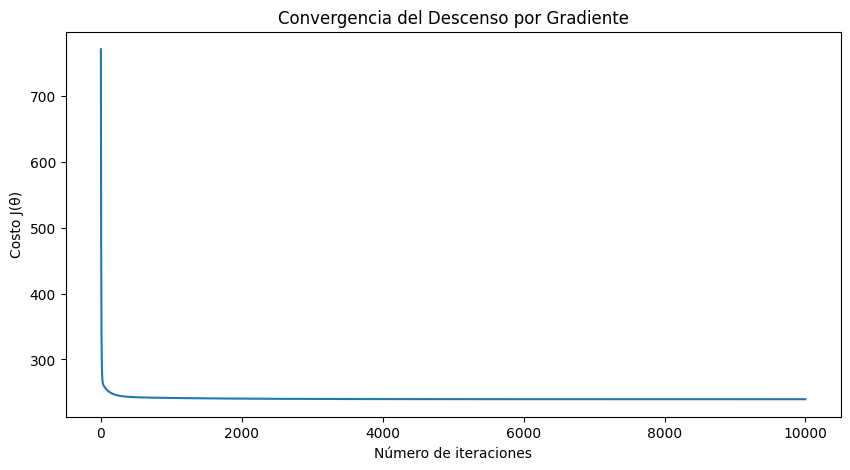

Costo inicial : 770.327018960621
Costo final   : 239.75655173710362
Reducción     : 68.87600384826176%


In [24]:
#Grafica de resultados tras las 10000 interacciones

pyplot.figure(figsize=(10, 5))
pyplot.plot(np.arange(len(J_history)), J_history)
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J(θ)')
pyplot.title('Convergencia del Descenso por Gradiente')
pyplot.show()

print(f"Costo inicial : {J_history[0]}")
print(f"Costo final   : {J_history[-1]}")
print(f"Reducción     : {((J_history[0] - J_history[-1]) / J_history[0]) * 100}%")

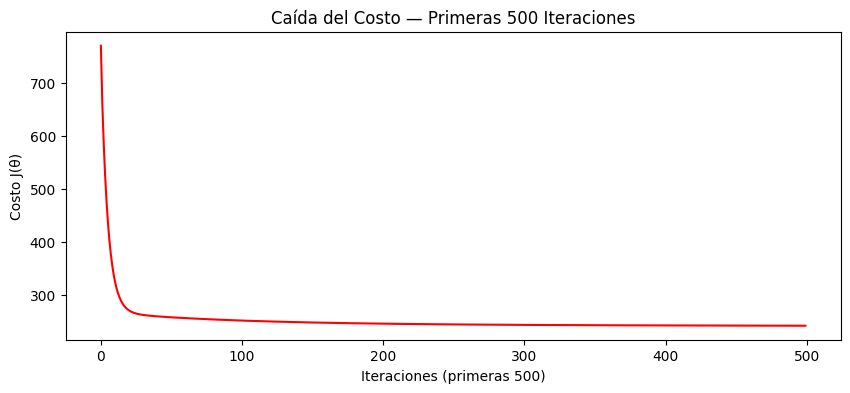

Costo en iteración   1: 770.327018960621
Costo en iteración 100: 252.56341080668665
Costo en iteración 500: 242.77440853941093


In [25]:
# Ver la caída del costo en las primeras iteraciones (fase más activa)
pyplot.figure(figsize=(10, 4))
pyplot.plot(np.arange(500), J_history[:500], color='red')
pyplot.xlabel('Iteraciones (primeras 500)')
pyplot.ylabel('Costo J(θ)')
pyplot.title('Caída del Costo — Primeras 500 Iteraciones')
pyplot.show()

print(f"Costo en iteración   1: {J_history[0]}")
print(f"Costo en iteración 100: {J_history[99]}")
print(f"Costo en iteración 500: {J_history[499]}")

## Ecuación Normal

Método alternativo al descenso por gradiente. Calcula θ directamente con una fórmula matemática (sin iteraciones):

$$\theta = (X^T X)^{-1} X^T y$$

**Ventaja:** resultado exacto en un solo cálculo.
**Desventaja:** muy lento si n (número de características) es muy grande (requiere invertir una matriz n×n).

In [30]:
# Ecuacion normal
def normalEqn(X, y):
    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)
    return theta


X_ne = np.concatenate([np.ones((m, 1)), X], axis=1)

# Calcular theta con la ecuación normal
theta_ne = normalEqn(X_ne, y)


# Costo con theta de la ecuación normal
J_ne = computeCostMulti(X_ne, y, theta_ne)
print()
print(f"  Costo J (Ecuación Normal)      : {J_ne:.4f}")
print(f"  Costo J (Descenso Gradiente)   : {J_history[-1]:.4f}")


  Costo J (Ecuación Normal)      : 239.7541
  Costo J (Descenso Gradiente)   : 239.7566


In [33]:
#prueba de prediccion del modelo en base a datos introducidos de manera manual

x_manual = np.array([
    162.71,   # 1 — wtd_std_ThermalConductivity
    399.97,   # 2 — range_ThermalConductivity
    205.00,   # 3 — range_atomic_radius
    153.81,   # 4 — std_ThermalConductivity
    4.03,     # 5 — wtd_mean_Valence
    1.36,     # 6 — wtd_entropy_atomic_mass
    3.91,     # 7 — wtd_gmean_Valence
    1.43,     # 8 — wtd_entropy_atomic_radius
    5,        # 9 — number_of_elements
    810.60    # 10 — range_fie
])

x_norm = (x_manual - mu) / sigma

# Agregar término de sesgo θ₀ (el "1" al inicio)
x_input_gd = np.concatenate([[1], x_norm])
x_input_ne = np.concatenate([[1], x_manual])

# Calcular predicciones con ambos métodos
pred_gradiente   = np.dot(x_input_gd, theta)
pred_ec_normal   = np.dot(x_input_ne, theta_ne)
pred_promedio    = (pred_gradiente + pred_ec_normal) / 2

# Mostrar resultados
print("   RESULTADO DE LA PREDICCIÓN")
print("  Valores ingresados:")
print()
print(f"  ► Predicción (Descenso Gradiente) : {pred_gradiente:.2f} K")
print(f"  ► Predicción (Ecuación Normal)    : {pred_ec_normal:.2f} K")
print(f"  ► Predicción promedio             : {pred_promedio:.2f} K")
print()
print(f"  Referencia — temperatura media del dataset: {y.mean():.2f} K")
print("=" * 50)

   RESULTADO DE LA PREDICCIÓN
  Valores ingresados:

  ► Predicción (Descenso Gradiente) : 55.61 K
  ► Predicción (Ecuación Normal)    : 55.58 K
  ► Predicción promedio             : 55.59 K

  Referencia — temperatura media del dataset: 34.42 K
